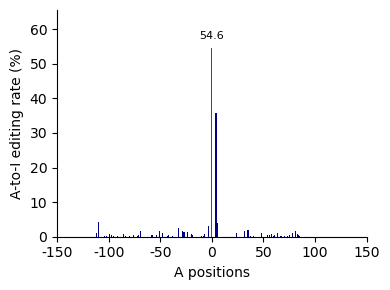

[DONE] Figure saved to: BMPR2_REWRITE_style.pdf


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_single_editor_bar(
    tsv_path,
    on_target_index,
    pdf_path,
    ymax=None,
    tick_step=50,
):
    """
    按 REWRITE-A 风格画单一靶点的 on-target / bystander 柱状图。

    参数
    ----
    tsv_path : str or Path
        单个扩增子对应的 *.base_mut.tsv / *.base_mut.filtered.tsv 路径。
    on_target_index : int
        on-target 的 chr_index（和表格里的 chr_index 一致）。
    pdf_path : str or Path
        输出 PDF 文件路径。
    ymax : float, optional
        y 轴上限（百分比）。若为 None，则根据数据自动设定。
    tick_step : int, optional
        x 轴刻度步长（bp），默认 50。
    """

    tsv_path = Path(tsv_path)
    pdf_path = Path(pdf_path)

    # ---------- 1. 读表 ----------
    df = pd.read_csv(tsv_path, sep="\t")

    # 兼容可能带 "#" 的列名（例如 "# chr_index"）
    rename_map = {}
    for col in df.columns:
        c = col.strip()
        if c.endswith("chr_name"):
            rename_map[col] = "chr_name"
        elif c.endswith("chr_index"):
            rename_map[col] = "chr_index"
        elif c.endswith("ref_base"):
            rename_map[col] = "ref_base"
        elif c == "A":
            rename_map[col] = "A"
        elif c == "G":
            rename_map[col] = "G"
        elif c == "C":
            rename_map[col] = "C"
        elif c == "T":
            rename_map[col] = "T"
        elif c.endswith("del_count"):
            rename_map[col] = "del_count"
        elif c.endswith("insert_count"):
            rename_map[col] = "insert_count"

    if rename_map:
        df = df.rename(columns=rename_map)

    # ---------- 2. 只保留 ref_base = A ----------
    df = df[df["ref_base"] == "A"].copy()

    # ---------- 3. 计算 coverage / editing_rate(%) ----------
    df["coverage"] = (
        df[["A", "G", "C", "T", "del_count", "insert_count"]].fillna(0).sum(axis=1)
    )

    # A-to-G 编辑率：用 G / coverage
    df["edit_rate"] = df["G"] / df["coverage"] * 100.0

    # ---------- 4. 构建相对坐标（A positions） ----------
    on_target_index = int(on_target_index)
    df["rel_pos"] = df["chr_index"].astype(int) - on_target_index

    # 按相对位置排序，x 轴从左到右
    df = df.sort_values("rel_pos")

    # ---------- 5. 颜色：on-target 红，其余蓝 ----------
    is_on = df["chr_index"].astype(int) == on_target_index
    colors = np.where(is_on, "red", "navy")

    # ---------- 6. 画图 ----------
    fig, ax = plt.subplots(figsize=(4.0, 3.0))

    ax.bar(df["rel_pos"], df["edit_rate"], color=colors, width=1.0)

    # y 轴范围
    if ymax is None:
        ymax = max(5.0, float(df["edit_rate"].max()) * 1.2)
    ax.set_ylim(0, ymax)

    # 轴标签
    ax.set_xlabel("A positions")
    ax.set_ylabel("A-to-I editing rate (%)")

    # 去掉上右边框
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---------- 7. x 轴刻度：每 tick_step 一个刻度 ----------
    rel_min = int(df["rel_pos"].min())
    rel_max = int(df["rel_pos"].max())

    # 让 0 尽量落在刻度上
    start = (rel_min // tick_step) * tick_step
    end = (rel_max // tick_step + 1) * tick_step
    ticks = list(range(start, end + 1, tick_step))

    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])

    # ---------- 8. 标注 on-target 编辑率 ----------
    if is_on.any():
        on_row = df[is_on].iloc[0]
        x0 = on_row["rel_pos"]
        y0 = on_row["edit_rate"]
        ax.text(
            x0,
            y0 + ymax * 0.03,
            f"{y0:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    fig.savefig(pdf_path, dpi=300)
    plt.show()
    plt.close(fig)
    print(f"[DONE] Figure saved to: {pdf_path}")


# 示例调用（在 notebook 里单独一个 cell 跑这一段）
plot_single_editor_bar(
    tsv_path="/Users/zhaohuanan/github/plots/single/BMPR2.10.cutoff_0.base_mut.tsv",
    on_target_index=134,
    pdf_path="./BMPR2_REWRITE_style.pdf",
    ymax=None,  # 或者手动给个值，比如 60
    tick_step=50,
)